In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')
sample_sub = pd.read_csv('../data/raw/sample_submission.csv')

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_sub.shape)

train: (1226237, 5)
test: (714688, 5)
sample_submission: (714688, 2)


In [220]:
print(f"Sütunların veri tipi: \n{train.dtypes}")
train.head()

Sütunların veri tipi: 
tanim           str
guc           int64
tarih           str
tuketim     float64
lokasyon        str
dtype: object


,tanim,guc,tarih,tuketim,lokasyon
0,70122340,1000,2025-01-01,5789.76,İZMİR>METROPOL>KARABAĞLAR
1,70142184,1250,2025-01-01,602.40,İZMİR>METROPOL>KARABAĞLAR
2,77540173,50,2025-01-01,19.92,MANİSA>GÖRDES
3,77540175,100,2025-01-01,25.64,MANİSA>GÖRDES
4,77540199,50,2025-01-01,10.98,MANİSA>GÖRDES


In [221]:
print(f"Train eksik değerler: \n{train.isna().sum()} \n")

print(f"Test eksik değerler: \n{test.isna().sum()}")

Train eksik değerler: 
tanim       0
guc         0
tarih       0
tuketim     0
lokasyon    0
dtype: int64 

Test eksik değerler: 
id          0
tanim       0
guc         0
tarih       0
lokasyon    0
dtype: int64


In [222]:
#train ve test tarihleri datetime'a çevir (coldstart kontrolü)
train['tarih'] = pd.to_datetime(train['tarih'])
test['tarih'] = pd.to_datetime(test['tarih'])

print("Train tarih aralığı:", train['tarih'].min(), "-", train['tarih'].max())
print("Test tarih aralığı:", test['tarih'].min(), "-", test['tarih'].max())

train_tanim = set(train['tanim'].unique())
test_tanim = set(test['tanim'].unique())

print("Train'deki unique trafo sayısı:", len(train_tanim)) 
print("Test'teki unique trafo sayısı:", len(test_tanim))
print("Test'te olup train'de olmayan trafo sayısı:", len(test_tanim - train_tanim))
print("Train'de olup test'te olmayan trafo sayısı:", len(train_tanim - test_tanim))


#!! Bulgu: Test'teki 7036 trafonun 2024'ü train'de hiç yok. Yani test setinin neredeyse üçte biri cold start -> bu trafolar için hiç geçmiş tüketim verimiz olmayacak.

Train tarih aralığı: 2025-01-01 00:00:00 - 2026-03-31 00:00:00
Test tarih aralığı: 2026-04-01 00:00:00 - 2026-07-31 00:00:00
Train'deki unique trafo sayısı: 5344
Test'teki unique trafo sayısı: 7036
Test'te olup train'de olmayan trafo sayısı: 2024
Train'de olup test'te olmayan trafo sayısı: 332


In [223]:
new_trafo = test_tanim - train_tanim

test_new = test[test['tanim'].isin(new_trafo)]
test_known = test[test['tanim'].isin(train_tanim)]

print("Yeni trafolar - guc istatistikleri: \n", test_new['guc'].describe())

print("\nBilinen trafolar - guc istatistikleri: \n", test_known['guc'].describe())

print("\nYeni trafolar - en sık lokasyonlar: \n", test_new['lokasyon'].value_counts().head(13))

print("\nBilinen trafolar - en sık lokasyonlar: \n", test_known['lokasyon'].value_counts().head(13))

## Bulgu: guc dağılımı yeni ve bilinen trafolarda benzer ->Mean: 676 vs 683 / Lokasyonlar da çok uzak değil (genellenebilir?)


Yeni trafolar - guc istatistikleri: 
 count    158369.000000
mean        676.713890
std         870.249229
min          40.000000
25%         250.000000
50%         630.000000
75%        1000.000000
max       30930.000000
Name: guc, dtype: float64

Bilinen trafolar - guc istatistikleri: 
 count    556319.000000
mean        683.975838
std        2172.301412
min          40.000000
25%         250.000000
50%         400.000000
75%        1000.000000
max       35900.000000
Name: guc, dtype: float64

Yeni trafolar - en sık lokasyonlar: 
 lokasyon
İZMİR>METROPOL>BORNOVA        17967
İZMİR>GÜNEY BÖLGE>MENDERES    10971
İZMİR>METROPOL>BAYRAKLI        9151
İZMİR>KUZEY BÖLGE>MENEMEN      7740
İZMİR>METROPOL>KARŞIYAKA       6066
İZMİR>METROPOL>KARABAĞLAR      5488
İZMİR>KUZEY BÖLGE>DİKİLİ       5293
İZMİR>GÜNEY BÖLGE>TORBALI      5151
İZMİR>METROPOL>BUCA            4745
İZMİR>METROPOL>KONAK           4531
MANİSA>YUNUSEMRE               4421
İZMİR>GÜNEY BÖLGE>ÖDEMİŞ       4313
MANİSA>SOMA         

count    1.226237e+06
mean     3.251897e+03
std      1.687821e+05
min      0.000000e+00
25%      2.604900e+02
50%      1.075200e+03
75%      2.748480e+03
max      5.040305e+07
Name: tuketim, dtype: float64

Negatif tuketim sayısı: 0

Sıfır tuketim sayısı: 57536


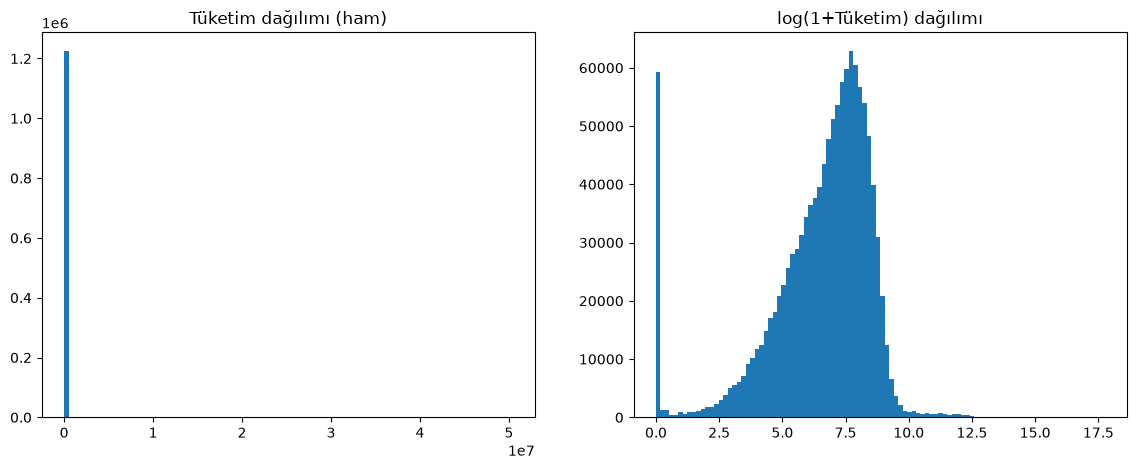

In [224]:
print(train['tuketim'].describe())
print("\nNegatif tuketim sayısı:", (train['tuketim'] < 0).sum())
print("\nSıfır tuketim sayısı:", (train['tuketim'] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train['tuketim'], bins=100)
axes[0].set_title('Tüketim dağılımı (ham)')

axes[1].hist(np.log1p(train['tuketim']), bins=100)
axes[1].set_title('log(1+Tüketim) dağılımı')
plt.show()

Aşırı outlier: Ham dağılımda max değer 50 milyon kWh // 75. persentil sadece 2748 iken fazla ve olağandışı bir sıçrama. std (168.782) ortalamadan (3.252) ekstra büyük --> tek tek bakılacak 

Sıfır tüketim kümesi (57.536 satır) log grafikte ana çan eğrisinden ayrı, sıfırda belirgin bir çubuk var. Bu, düşük-tüketimli günlerin doğal kuyruğu değil, ayrı bir kategori gibi duruyor (arıza/sayaç kesintisi ya da gerçekten pasif trafo). Rastgele mi dağılmış yoksa belirli trafolarda mı yoğunlaşmış bakılacak kontrol lazım.

In [225]:
print(train.nlargest(10, 'tuketim')[['tanim','guc','tarih','tuketim','lokasyon']]) # en büyük tüketim değerleri

# Sıfır tüketimin trafo bazında dağılımı
zero_by_trafo = train[train['tuketim'] == 0].groupby('tanim').size().sort_values(ascending=False)
print("\n Sıfır günü olan trafo sayısı:", zero_by_trafo.shape[0], "/ toplam trafo:", train['tanim'].nunique())
print(zero_by_trafo.head(10))

zero_ratio = train.groupby('tanim')['tuketim'].apply(lambda x: (x == 0).mean())
print(f"\nTrafo bazlı sıfır tüketim oranı: \n",zero_ratio.describe())

            tanim    guc      tarih     tuketim                   lokasyon
1106137  75010709  35800 2026-01-26  50403051.0  İZMİR>METROPOL>KARABAĞLAR
790748   75010709  35800 2026-02-10  48324398.4  İZMİR>METROPOL>KARABAĞLAR
837676   75020108  35800 2025-07-12  45631701.0       İZMİR>METROPOL>KONAK
917916   75020108  35800 2025-08-16  45407230.2       İZMİR>METROPOL>KONAK
499994   75010304  35800 2025-12-25  45155642.4       İZMİR>METROPOL>KONAK
581529   75090407  35800 2026-01-30  45028999.8    İZMİR>METROPOL>BAYRAKLI
242303   75020108  35800 2026-02-13  44765323.2       İZMİR>METROPOL>KONAK
943531   75020108  35800 2025-12-17  44303837.4       İZMİR>METROPOL>KONAK
275331   75020108  35800 2025-11-14  43551806.4       İZMİR>METROPOL>KONAK
76186    75020108  35800 2025-11-04  43518355.2       İZMİR>METROPOL>KONAK

 Sıfır günü olan trafo sayısı: 552 / toplam trafo: 5344
tanim
72240114     455
75010705     455
70421989     455
700601469    455
700594714    455
70121764     455
700631202 

75020108 trafosu top-10'da 5 kez tekrarlıyor --> rastgele gürültü değil, sistematik bir sorun var.

guc=35800 kVA olan bir trafo, teorik olarak 24 saat × 35800 kVA maksimum bu civarda enerji tüketebilir. Ama gördüğümüz değerler 50 milyon kWh burada bir sorun var 

Zero tarafındaysa train aralığı (2025-01-01 - 2026-03-31) tam 455 gün bazı trafolarda "455 sıfır günü" görmemiz, o trafoların train'deki tüm süre boyunca hiç aktif olmadığı anlamına geliyor.

In [226]:
# 1) her zaman sıfır olan trafo sayısı
zero_ratio = train.groupby('tanim')['tuketim'].apply(lambda x: (x == 0).mean())
print("zero_ratio tam istatistik: \n", zero_ratio.describe())

print("\nTamamen (ratio=1.0) sıfır olan trafo sayısı: ", (zero_ratio == 1.0).sum())

always_zero_trafo = zero_ratio[zero_ratio == 1.0].index
print("Bu trafolardan test'te de bulunan:", test[test['tanim'].isin(always_zero_trafo)]['tanim'].nunique())


# 2) imkansız değerleri işaretle
train['max_teorik'] = train['guc'] * 24  # kVA * 24 saat ~ üst sınır (kWh)
train['asiri_oran'] = train['tuketim'] / train['max_teorik']

print("\nasiri_oran > 2 olan satır sayısı (teorik tavanın 2 katından fazla):", (train['asiri_oran'] > 2).sum())
print(train[train['asiri_oran'] > 2].sort_values('asiri_oran', ascending=False)[['tanim','guc','tarih','tuketim','asiri_oran']].head(15))

#298 trafo train'de tamamen sıfır, bunların 234'ü test'te de var. Bu trafolar için güvenle yaklaşık sıfır tahmin edilebilir. 
#444 satır (toplam satırda küçük bir oran) ama fiziksel olarak imkânsız, en kötüsü teorik tavanın 58 katı olan var. 75020108 ve 75010709 gibi birkaç belirli trafoda süregelen bir veri sorunu 

zero_ratio tam istatistik: 
 count    5344.000000
mean        0.067771
std         0.242230
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: tuketim, dtype: float64

Tamamen (ratio=1.0) sıfır olan trafo sayısı:  298
Bu trafolardan test'te de bulunan: 234

asiri_oran > 2 olan satır sayısı (teorik tavanın 2 katından fazla): 444
            tanim    guc      tarih     tuketim  asiri_oran
1106137  75010709  35800 2026-01-26  50403051.0   58.662769
790748   75010709  35800 2026-02-10  48324398.4   56.243480
837676   75020108  35800 2025-07-12  45631701.0   53.109522
917916   75020108  35800 2025-08-16  45407230.2   52.848266
499994   75010304  35800 2025-12-25  45155642.4   52.555450
581529   75090407  35800 2026-01-30  45028999.8   52.408054
779655   75020410  10900 2025-08-09  13677892.2   52.285521
242303   75020108  35800 2026-02-13  44765323.2   52.101168
943531   75020108  35800 2025-12-17  44303837.4   51.564057
275331   7

In [227]:
#Outlierlar nerelerde ve ne kadar yoğun
outliers = train[train['asiri_oran'] > 2]
print("Outlier içeren farklı trafo sayısı:", outliers['tanim'].nunique(), ", toplam:", train['tanim'].nunique())

print("Trafo başına en çok outlier olanlar ve sayısı: \n", outliers['tanim'].value_counts().head(15))



Outlier içeren farklı trafo sayısı: 23 , toplam: 5344
Trafo başına en çok outlier olanlar ve sayısı: 
 tanim
75082213    113
72030261     95
75020110     78
77840445     60
75162401     15
75010202     11
77140232     10
75020108      8
71530512      8
75020101      7
75010313      6
75101912      5
75020402      5
75010708      4
75010709      4
Name: count, dtype: int64


Outlier'ların 444'ünün %78'i sadece 4 trafoda (75082213, 72030261, 75020110, 77840445) yoğunlaşmış, toplamda sadece 23 trafo etkileniyor. Bu, birkaç trafoda süregelen bir ölçüm/veri aktarım sorunu olduğunu gösteriyor (rastgele gürültü değil). Trafo bazlı düzeltme ile Feature Eng. aşamasında 23 trafoyu düzelteceğiz sorun lokalde medyan ve komşu gün ortalaması ile dolduracağız (not edildi yapılacak).

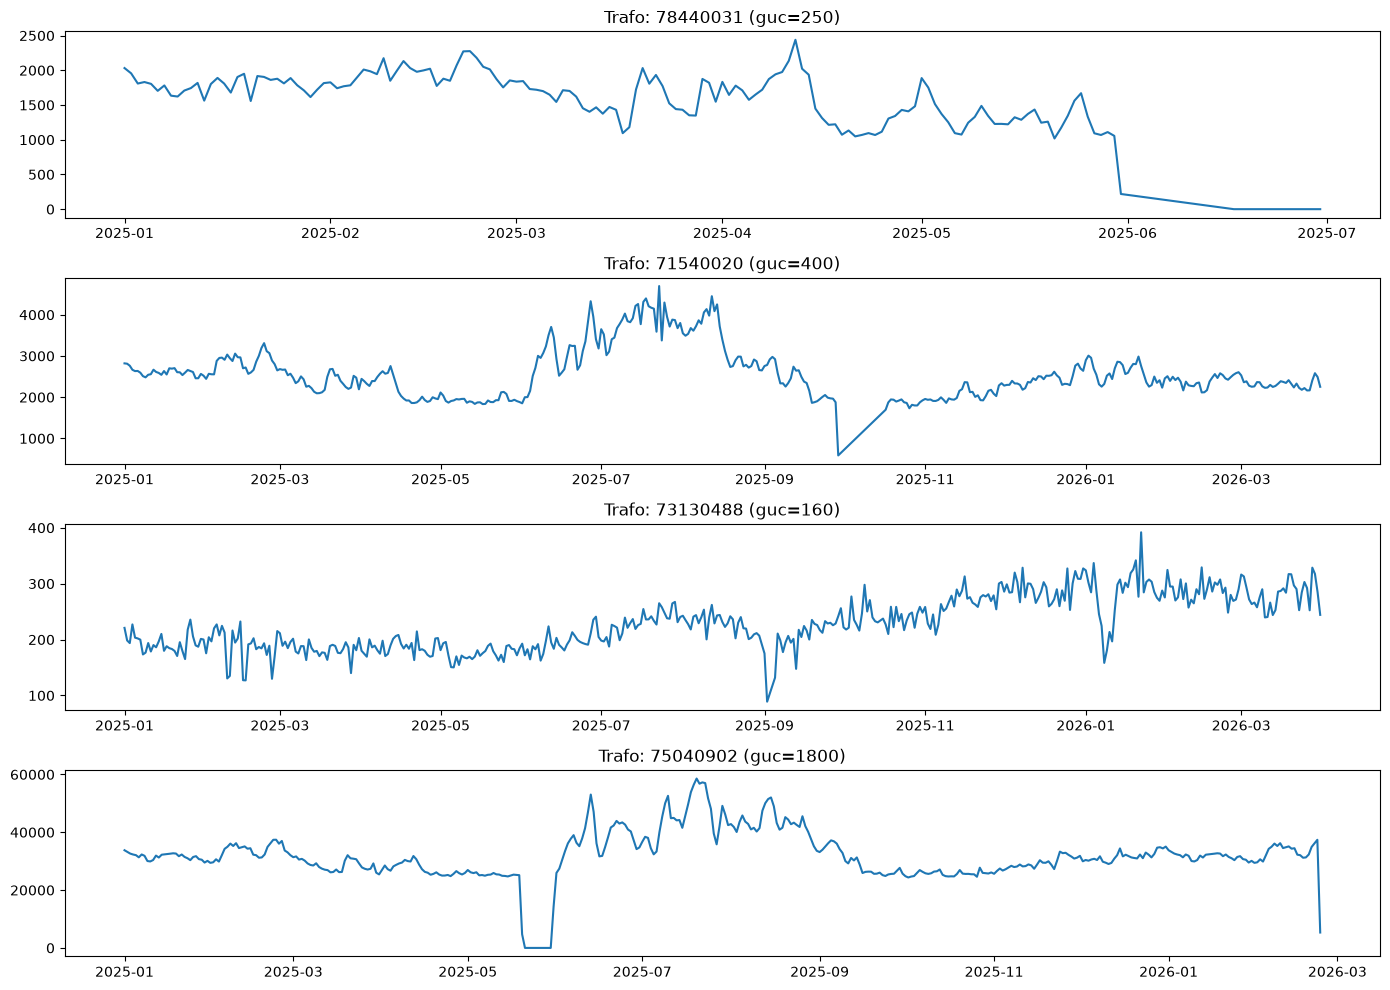


haftalık: gun_adi
Monday       2751.336733
Tuesday      3896.775850
Wednesday    2843.728496
Thursday     3128.797811
Friday       3357.794733
Saturday     3922.708940
Sunday       2857.916291
Name: tuketim, dtype: float64 

ay
1     3189.835611
2     3150.795025
3     2935.734988
4     2468.196311
5     2036.343450
6     3573.244313
7     5459.246940
8     4396.277358
9     3880.936840
10    2246.962530
11    2976.385637
12    3211.995309
Name: tuketim, dtype: float64


In [228]:
# Birkaç normal (outlier olmayan) trafonun zaman serisi
normal_trafolar = train[~train['tanim'].isin(outliers['tanim'].unique())]['tanim'].unique()
ornek_trafolar = np.random.choice(normal_trafolar, 4, replace=False)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for i, t in enumerate(sample_trafolar):
    sub = train[train['tanim'] == t].sort_values('tarih')
    axes[i].plot(sub['tarih'], sub['tuketim'])
    axes[i].set_title(f"Trafo: {t} (guc={sub['guc'].iloc[0]})")
plt.tight_layout()
plt.show()

# Haftanın günlerine göre ortalama tüketim
train['gun_adi'] = train['tarih'].dt.day_name()
haftalik = train.groupby('gun_adi')['tuketim'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(f"\nhaftalık: {haftalik} \n")

# Aylara göre ortalama tüketim
train['ay'] = train['tarih'].dt.month
aylik = train.groupby('ay')['tuketim'].mean()
print(aylik)

1. Yaz mevsimselliği: Aylık ortalama Temmuz'da (5459) Nisan'a (2036) göre 2.7 kat beklendik şekilde -> klima/soğutma talebi paterni. Test periyodu tam da Nisan-Temmuz 2026'yı kapsıyor, yani bu artışın ortasında kalıyor. Bu, dışarıdan hava durumu (özellikle sıcaklık) verisi eklemek lazım şart!

2. Haftalık ortalama şüpheli görünüyor: Salı (3896) ve Cumartesi (3922) en yüksek, Pazartesi (2751) en düşük — beklenen "hafta içi yüksek/hafta sonu düşük" paterni net değil. Bunun nedeni muhtemelen outlier'ları henüz filtrelemeden ortalama aldık daha önce bulduğumuz 50 milyon kWh'lik satırlar bu ortalamayı çarpıtıyor olabilir. Medyan ile tekrar bakmamız lazım. sonradan kontrol edeceğiz yine aklımda

3. Bulgu: bazı trafoların veri aralığı eksik: 78440031 grafiği 2025-06'da bitiyor (sonra veri yok), 75040902 da 2026-02'de kesiliyor. Yani her trafo Ocak2025-Mart2026 boyunca kayıtlı değil — bazıları erken devreye girmiş/çıkmış olabilir. Bu, lag/rolling feature oluştururken dikkat etmemiz gereken bir boşluk kaynağı. buna bakılacak

4. Uzun süreli kesinti dönemleri: 71540020 ve 75040902'de birkaç haftalık sıfıra yakın dönemler var (muhtemelen bakım/arıza) -> tek günlük "0" analizinin yakalayamadığı pattern var. kontrol edilecek!

In [229]:
# Bu 4 bulguyu netleştirmek adına: 

# Medyan ile haftalık/aylık (outlier'lardan daha az etkilenir)
haftalik_medyan = train.groupby('gun_adi')['tuketim'].median().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(haftalik_medyan)

aylik_medyan = train.groupby('ay')['tuketim'].median()
print(aylik_medyan)

print()

# Trafo bazında veri aralığı tamlığı
trafo_araligi = train.groupby('tanim')['tarih'].agg(['min','max','count'])
trafo_araligi['beklenen_gun'] = (trafo_araligi['max'] - trafo_araligi['min']).dt.days + 1
trafo_araligi['eksik_gun'] = trafo_araligi['beklenen_gun'] - trafo_araligi['count']

print("Tam periyoda (455 gün) sahip trafo sayısı:", (trafo_araligi['count'] == 455).sum(), "/", len(trafo_araligi))
print(trafo_araligi['count'].describe())
print("Erken biten/geç başlayan trafo örnekleri:",trafo_araligi.sort_values('count').head(10))

# Sadece 1253/5344 trafo tam 455 günlük veriye sahip; medyan sadece 170 gün, ve bazı trafolarda tam 1 günlük kayıt var.
# Üstelik bu tek-günlük kayıtlar tarih aralığının her yerine dağılmış (2025-01, 2025-05, 2025-07, 2025-08, 2026-01, 2026-03)
# Düzensiz sayaç okuma var düz bir pattarn sorun değil 


# Medyan bazlı örüntüler net: hafta içinde belirgin bir düşüş yok ama Pazar en düşük (1014); 
# Aylık mevsimsellik hâlâ güçlü (Temmuz 1684 vs Mayıs/Ekim ~825)

gun_adi
Monday       1075.32
Tuesday      1081.88
Wednesday    1090.56
Thursday     1097.38
Friday       1085.30
Saturday     1083.02
Sunday       1014.08
Name: tuketim, dtype: float64
ay
1     1103.04
2     1084.88
3      995.20
4      877.76
5      821.90
6     1196.80
7     1683.76
8     1502.34
9     1096.72
10     831.60
11     882.18
12    1090.62
Name: tuketim, dtype: float64

Tam periyoda (455 gün) sahip trafo sayısı: 1253 / 5344
count    5344.000000
mean      229.460516
std       171.546547
min         1.000000
25%        82.000000
50%       170.000000
75%       453.000000
max       455.000000
Name: count, dtype: float64
Erken biten/geç başlayan trafo örnekleri:                  min        max  count  beklenen_gun  eksik_gun
tanim                                                          
700444233 2025-01-06 2025-01-06      1             1          0
72630329  2025-05-28 2025-05-28      1             1          0
70142010  2025-08-04 2025-08-04      1             1          0


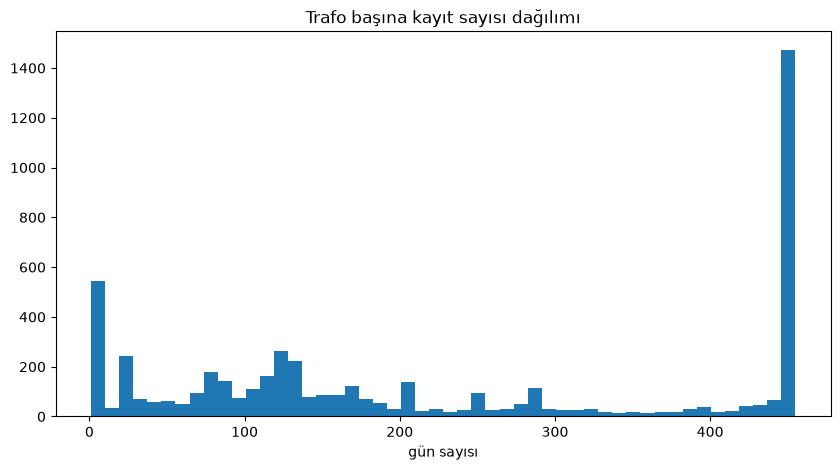

eksik_gun > 0 olan trafo sayısı (aralık içinde boşluk var): 1240
count    5344.000000
mean       13.064371
std        44.096405
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       446.000000
Name: eksik_gun, dtype: float64


In [230]:
plt.figure(figsize=(10,5))
plt.hist(trafo_araligi['count'], bins=50)
plt.title("Trafo başına kayıt sayısı dağılımı")
plt.xlabel("gün sayısı")
plt.show()

# eksik_gun (aralık içindeki boşluklar) - trafo hiç mi eksik yoksa arada boşluk mu var
print("eksik_gun > 0 olan trafo sayısı (aralık içinde boşluk var):", (trafo_araligi['eksik_gun'] > 0).sum())
print(trafo_araligi['eksik_gun'].describe())

Kısa geçmişli trafoları atmamıza gerek yok. sadece "elimizdeki kadar" geçmişle lag/rolling feature üretip eksik pencereleri NaN/fallback ile doldurmak kafi olacak ama 1240 trafodaki iç boşluklar için lag hesaplarken satır sırasına değil, gerçek tarihe göre hizalamak gerekiyor. yoksa boşluk öncesi/sonrası günler yanlışlıkla ardışık sayılabilir.



TOPLU EDA SÜRECİ: 

1-Outlier düzeltme —> 23 problemli trafonun >2x teorik tavan üstü günlerini trafo medyanıyla değiştir.
2-Takvim özellikleri —> gün, ay, hafta içi/sonu, yıl içi gün sırası (mevsimsellik için).
3-Trafo statik özellikleri —> guc, lokasyon (İL/BÖLGE/İLÇE parçalanmış olarak ayrı sütunlar).
4-Geçmişe dayalı özellikler eğer varsa -> trafo bazlı lag (1, 7, 30 gün), rolling ortalama/medyan (7, 30 gün) tarihe göre hizalanmış, eksikse NaN bırakılıp model LightGBM NaN'ı native destekler veya lokasyon+guc ortalamasıyla fallback.
5-Grup istatistikleri (cold-start fallback) —> lokasyon + guc-bucket bazlı ortalama/medyan tüketim (tüm trafolarda hesaplanabilir, yeni trafolarda da geçerli).
6-Dış veri —> hava durumu (sıcaklık, özellikle) ve özel gün/tatil verisi ekleme (nereden çekileceği araştırılacak).
7-Zaman bazlı CV —> hem "gelecek tarih" hem "görülmemiş trafo" senaryosunu simüle eden bir validation seti.
8-Baseline model —> LightGBM, hedefi log1p(tuketim) olarak eğitip tahminde expm1 ile geri çevirmek (RMSLE ile doğal uyum verir).

In [231]:
# 1 - OUTLİER DÜZELTME (23 ADET PROBLEMLİ TRAFO BULMUŞTUK)

# Trafo medyanı ile outlier düzeltme (asiri_oran > 2 olan satırlar)
train['tuketim_duzeltilmis'] = train['tuketim']

for t in outliers['tanim'].unique():
    trafo_medyan = train.loc[(train['tanim'] == t) & (train['asiri_oran'] <= 2), 'tuketim'].median()
    mask = (train['tanim'] == t) & (train['asiri_oran'] > 2)
    train.loc[mask, 'tuketim_duzeltilmis'] = trafo_medyan

print("Düzeltilen satır sayısı: ", (train['tuketim'] != train['tuketim_duzeltilmis']).sum() )
print(train.loc[train['tuketim'] != train['tuketim_duzeltilmis'], ['tanim','tuketim','tuketim_duzeltilmis']].head(13))

#Her problemli trafo için, outlier olmayan günlerinin medyanını hesaplayıp sadece outlier günlerini bu medyanla değiştiriyoruz.
#Trafonun kendi normal seviyesini koruyarak sadece bozuk günleri düzeltmiş oluyoruz.

Düzeltilen satır sayısı:  444
          tanim     tuketim  tuketim_duzeltilmis
6901   75020110   44147.250           22379.1750
18247  75082213   22548.750           16060.5375
19844  75082213   25113.900           16060.5375
20899  75082213   23904.300           16060.5375
20959  75020110   63052.500           22379.1750
21740  75010202   50169.000           11441.8500
23696  75082213   24042.900           16060.5375
26674  75020110   50138.550           22379.1750
37960  75082213   22639.575           16060.5375
38580  77141866  132523.520             321.9200
39550  75082213   26122.950           16060.5375
41467  75010202   45033.450           11441.8500
42356  75082213   22830.150           16060.5375


In [232]:
#lokasyonu split edelim
lokasyon_split = train['lokasyon'].str.split('>', expand=True)
train['il'] = lokasyon_split[0]
train['bolge'] = lokasyon_split[1]
train['ilce'] = lokasyon_split[2] if lokasyon_split.shape[1] > 2 else np.nan

print(train[['lokasyon','il','bolge','ilce']].head(13))

print("Kaç farklı ilce:", train['ilce'].nunique())
print("Kaç farklı il:", train['il'].nunique())
print("Kaç farklı bolge:", train['bolge'].nunique())

print("İlçe eksik (None) sayısı:", train['ilce'].isna().sum())
print("İl eksik (None) sayısı:", train['il'].isna().sum())
print("Bölge eksik (None) sayısı:", train['bolge'].isna().sum())

# İlçe eksik (None) sayısı: 327616 kontrol gerekli (ilçesiz kayıtlar)


                     lokasyon      il        bolge        ilce
0   İZMİR>METROPOL>KARABAĞLAR   İZMİR     METROPOL  KARABAĞLAR
1   İZMİR>METROPOL>KARABAĞLAR   İZMİR     METROPOL  KARABAĞLAR
2               MANİSA>GÖRDES  MANİSA       GÖRDES         NaN
3               MANİSA>GÖRDES  MANİSA       GÖRDES         NaN
4               MANİSA>GÖRDES  MANİSA       GÖRDES         NaN
5     İZMİR>METROPOL>BAYRAKLI   İZMİR     METROPOL    BAYRAKLI
6   İZMİR>METROPOL>KARABAĞLAR   İZMİR     METROPOL  KARABAĞLAR
7      İZMİR>METROPOL>BORNOVA   İZMİR     METROPOL     BORNOVA
8        İZMİR>METROPOL>KONAK   İZMİR     METROPOL       KONAK
9        İZMİR>METROPOL>KONAK   İZMİR     METROPOL       KONAK
10  İZMİR>METROPOL>KARABAĞLAR   İZMİR     METROPOL  KARABAĞLAR
11       İZMİR>METROPOL>KONAK   İZMİR     METROPOL       KONAK
12  İZMİR>GÜNEY BÖLGE>TORBALI   İZMİR  GÜNEY BÖLGE     TORBALI
Kaç farklı ilce: 30
Kaç farklı il: 2
Kaç farklı bolge: 20
İlçe eksik (None) sayısı: 327616
İl eksik (None) sayısı: 0
B

In [233]:
# İlçe eksik (None) sayısı: 327616 kontrol gerekli (ilçesiz kayıtlar) için kontroller!

print(train['lokasyon'].str.count('>').value_counts())
print("\nHiyerarşi seviyesi 0 (hiç '>' yok) olan unique değerler: \n", train[train['lokasyon'].str.count('>') == 0]['lokasyon'].unique())
print("\nHiyerarşi seviyesi 1 (sadece İL>BÖLGE) olan örnekler: \n", train[train['lokasyon'].str.count('>') == 1]['lokasyon'].unique()[:10])

# Hiyerarşi seviyesi 0 (tamamen jenerik "GEDİZ EDAŞ" gibi belirsiz) hiç yok -> eksik ilçe'ler sadece MANİSA'nın veri yapısında ilçe kırılımı olmamasından kaynaklanıyor (İZMİR>METROPOL>KARABAĞLAR gibi 3 seviyeli, MANİSA>GÖRDES gibi 2 seviyeli). 
# Bu belirsizlik değil, yapısal bir fark placeholder ile dolduracağımız anlaşıldı. "YOK" ataması yapılacak.

lokasyon
2    898621
1    327616
Name: count, dtype: int64

Hiyerarşi seviyesi 0 (hiç '>' yok) olan unique değerler: 
 <StringArray>
[]
Length: 0, dtype: str

Hiyerarşi seviyesi 1 (sadece İL>BÖLGE) olan örnekler: 
 <StringArray>
[   'MANİSA>GÖRDES',   'MANİSA>SARIGÖL',      'MANİSA>KULA',
   'MANİSA>AKHİSAR',      'MANİSA>SOMA',   'MANİSA>DEMİRCİ',
  'MANİSA>TURGUTLU', 'MANİSA>KÖPRÜBAŞI', 'MANİSA>YUNUSEMRE',
  'MANİSA>KIRKAĞAÇ']
Length: 10, dtype: str


In [234]:
#İlçeyi doldur + takvim özellikleri

train['ilce'] = train['ilce'].fillna('YOK')

# Takvim özellikleri
train['yil'] = train['tarih'].dt.year
train['ay'] = train['tarih'].dt.month
train['gun'] = train['tarih'].dt.day
train['haftanin_gunu'] = train['tarih'].dt.dayofweek  # 0=Pazartesi
train['hafta_sonu'] = (train['haftanin_gunu'] >= 5).astype(int)
train['yilin_gunu'] = train['tarih'].dt.dayofyear

print(train[['tarih','yil','ay','gun','haftanin_gunu','hafta_sonu','yilin_gunu']].head(12))

        tarih   yil  ay  gun  haftanin_gunu  hafta_sonu  yilin_gunu
0  2025-01-01  2025   1    1              2           0           1
1  2025-01-01  2025   1    1              2           0           1
2  2025-01-01  2025   1    1              2           0           1
3  2025-01-01  2025   1    1              2           0           1
4  2025-01-01  2025   1    1              2           0           1
5  2025-01-01  2025   1    1              2           0           1
6  2025-01-01  2025   1    1              2           0           1
7  2025-01-01  2025   1    1              2           0           1
8  2025-01-01  2025   1    1              2           0           1
9  2025-01-01  2025   1    1              2           0           1
10 2025-01-01  2025   1    1              2           0           1
11 2025-01-01  2025   1    1              2           0           1


In [235]:
# guc'ı bucket(aralıklara) bölüp il+bolge ile birleştirerek "bu bölgede, bu güç aralığındaki trafolar ortalama ne kadar tüketiyor" istatistiğini çıkar. 
#Bu, cold-start (train'de hiç olmayan) trafolar için sağlam fallback feature olacak çünkü her yeni trafonun guc ve lokasyon'u bilinir, geçmişi bilinmez.

guc_bins = [0, 100, 250, 500, 1000, 2000, 5000, np.inf] 
train['guc_bucket'] = pd.cut(train['guc'], bins=guc_bins)

grup_istatistik = train.groupby(['il','bolge','guc_bucket'], observed=True)['tuketim_duzeltilmis'].agg(
    grup_ortalama='mean', grup_medyan='median'
).reset_index()

print(grup_istatistik)
print("Kaç farklı grup:", len(grup_istatistik))

        il     bolge        guc_bucket  grup_ortalama  grup_medyan
0   MANİSA   AHMETLİ      (0.0, 100.0]     296.289472       220.32
1   MANİSA   AHMETLİ    (100.0, 250.0]     709.625104       616.72
2   MANİSA   AHMETLİ    (250.0, 500.0]     584.035967       551.76
3   MANİSA   AHMETLİ   (500.0, 1000.0]    2186.427168      1905.40
4   MANİSA   AKHİSAR      (0.0, 100.0]     168.337544        73.46
..     ...       ...               ...            ...          ...
92   İZMİR  METROPOL    (250.0, 500.0]    2433.907208      2249.40
93   İZMİR  METROPOL   (500.0, 1000.0]    3429.088985      2931.60
94   İZMİR  METROPOL  (1000.0, 2000.0]    4901.560636      3840.40
95   İZMİR  METROPOL  (2000.0, 5000.0]    5065.642023      3261.40
96   İZMİR  METROPOL     (5000.0, inf]   54881.260198     25295.40

[97 rows x 5 columns]
Kaç farklı grup: 97


In [236]:
#Grup istatistiklerini train'e merge + trafo bazlı lag/rolling özelliklerine bak

train = train.merge(grup_istatistik, on=['il','bolge','guc_bucket'], how='left')

# Trafo bazlı lag/rolling (tarihe göre sıralı)
train = train.sort_values(['tanim','tarih']).reset_index(drop=True)

train['lag_1'] = train.groupby('tanim')['tuketim_duzeltilmis'].shift(1)
train['lag_7'] = train.groupby('tanim')['tuketim_duzeltilmis'].shift(7)
train['rolling_7_ortalama'] = train.groupby('tanim')['tuketim_duzeltilmis'].shift(1).rolling(7).mean().reset_index(0, drop=True)
train['rolling_30_ortalama'] = train.groupby('tanim')['tuketim_duzeltilmis'].shift(1).rolling(30).mean().reset_index(0, drop=True)

print("lag/rolling NaN oranları: \n", train[['lag_1','lag_7','rolling_7_ortalama','rolling_30_ortalama']].isna().mean())


lag/rolling NaN oranları: 
 lag_1                  0.004358
lag_7                  0.028597
rolling_7_ortalama     0.028597
rolling_30_ortalama    0.117065
dtype: float64


merge ile her satıra bu trafonun ait olduğu grubun ortalama/medyan tüketimini ekliyoruz -> cold-start ve genel sinyal için. Lag/rolling'de kritik nokta: groupby('tanim') ile her trafo kendi içinde hesaplanıyor (başka trafonun verisi karışmıyor), ve shift(1) kullanıyoruz çünkü bugünün tahminini yaparken bugünün gerçek değerini kullanamayız (data leakage olur)sadece geçmiş günler. rolling(7/30) da shift edilmiş seri üzerine kuruldu aynı sebeple. NaN oranını görmek önemli çünkü daha önce bulduğumuz gibi trafoların çoğunda kısıtlı geçmiş var LightGBM NaN'ı native desteklediği için sorun değil ama yine de.


NaN oranları düşük çıktı (lag_1 sadece %0.4, rolling_30 %11.7) bunun nedeni, veri satır sayısı ağırlıklı bir ortalama olması: uzun geçmişli trafolar toplam satır sayısında daha baskın, kısa geçmişliler nispeten az satır katıyor. Oranlar sorunsuz LightGBM native NaN desteği var

In [ ]:
# 1- Amaç: modelin bu gün resmi tatil, tüketim düşük olacak bilgisini doğrudan görmesi için. Tatilleri traine işaretle)

tatil_tarihleri_2025 = [
    '2025-01-01', # yılbaşı
    '2025-03-29','2025-03-30','2025-03-31','2025-04-01',  # ramazan bayramı
    '2025-04-23','2025-05-01','2025-05-19', #resmi tatiller
    '2025-06-05','2025-06-06','2025-06-07','2025-06-08','2025-06-09',  # kurban bayramı
    '2025-08-30','2025-10-29', # resmi tatiller
] 
tatil_tarihleri_2026 = [
    '2026-04-23','2026-05-01','2026-05-19', #resmi tatiller
    '2026-05-26','2026-05-27','2026-05-28','2026-05-29','2026-05-30',  # kurban bayramı
]
tum_tatiller = pd.to_datetime(tatil_tarihleri_2025 + tatil_tarihleri_2026)

train['tatil'] = train['tarih'].isin(tum_tatiller).astype(int)

print("Train'de tatil olarak işaretlenen satır sayısı:", train['tatil'].sum())
print(train[train['tatil']==1]['tarih'].dt.date.unique())

Train'de tatil olarak işaretlenen satır sayısı: 33113
[datetime.date(2025, 1, 1) datetime.date(2025, 3, 29)
 datetime.date(2025, 3, 30) datetime.date(2025, 3, 31)
 datetime.date(2025, 4, 1) datetime.date(2025, 4, 23)
 datetime.date(2025, 5, 1) datetime.date(2025, 5, 19)
 datetime.date(2025, 6, 5) datetime.date(2025, 6, 6)
 datetime.date(2025, 6, 7) datetime.date(2025, 6, 8)
 datetime.date(2025, 6, 9) datetime.date(2025, 8, 30)
 datetime.date(2025, 10, 29)]


In [ ]:
# 2-
k = 30  # shrinkage gücü: küçük gruplarda genel ortalamaya ne kadar çekileceğini belirler
genel_ortalama = train['tuketim_duzeltilmis'].mean()

grup_ham = train.groupby(['il','bolge','guc_bucket'], observed=True)['tuketim_duzeltilmis'].agg(
    grup_toplam='sum', grup_sayi='count'
).reset_index()

grup_ham['grup_ortalama'] = (grup_ham['grup_toplam'] + k * genel_ortalama) / (grup_ham['grup_sayi'] + k)

print(grup_ham[['il','bolge','guc_bucket','grup_sayi','grup_ortalama']].sort_values('grup_sayi').head())
print(" \nÖrnek: 2 satırlık grubun eski (ham) ortalaması vs yeni (shrinkage'lı) ortalaması \n")


grup_ham['grup_ortalama_HAM'] = grup_ham['grup_toplam'] / grup_ham['grup_sayi']

karsilastir = grup_ham[['il','bolge','guc_bucket','grup_sayi','grup_ortalama_HAM','grup_ortalama']]
print(karsilastir.sort_values('grup_sayi').head())
print(karsilastir.sort_values('grup_sayi', ascending=False).head())

        il      bolge        guc_bucket  grup_sayi  grup_ortalama
50  MANİSA    SARIGÖL  (1000.0, 2000.0]          2    2318.356612
14  MANİSA   ALAŞEHİR  (1000.0, 2000.0]          2    2389.194112
35  MANİSA       KULA  (1000.0, 2000.0]          6    2139.553100
38  MANİSA  KÖPRÜBAŞI    (250.0, 500.0]         71    1300.672194
55  MANİSA  SARUHANLI  (1000.0, 2000.0]         97     584.152847
 
Örnek: 2 satırlık grubun eski (ham) ortalaması vs yeni (shrinkage'lı) ortalaması 

        il      bolge        guc_bucket  grup_sayi  grup_ortalama_HAM  \
50  MANİSA    SARIGÖL  (1000.0, 2000.0]          2           0.000000   
14  MANİSA   ALAŞEHİR  (1000.0, 2000.0]          2        1133.400000   
35  MANİSA       KULA  (1000.0, 2000.0]          6         472.750000   
38  MANİSA  KÖPRÜBAŞI    (250.0, 500.0]         71         805.358873   
55  MANİSA  SARUHANLI  (1000.0, 2000.0]         97           0.000000   

    grup_ortalama  
50    2318.356612  
14    2389.194112  
35    2139.553100  


Daha önce (il, bölge, guç aralığı) bazında 97 grup çıkmıştı ama bazıları çok az örnekliydi 2-6 satır gibi örnek vardı. Bu küçük grupların ham ortalaması outlierlı çıkıyordu, hatta SARUHANLI örneğinde tamamen sıfırdı çünkü o gruptaki tek trafo her zaman sıfır trafolardan biriydi. Shrink sebebi: Bu ham sıfır ortalamayı doğrudan kullanılsaydı, yarın bu gruba (aynı lokasyon+güç profili) düşecek cold-start bir trafo için de 0 tüketir tahmini üretirdik fakat o yeni trafo muhtemelen normal bir trafo, sadece grubun tek üyesi arızalıydı. Shrinkage formülü küçük grupları genel ortalamaya doğru çekerek bu yanlış güveni düzeltmiş oldu. (SARUHANLI 0 -> 584'e çekildi), büyük gruplarda (100 binlerce satır) ise pratikte hiçbir şeyi değiştirmedi (623.18 -> 623.49) istenen olması gereken davranış.

In [ ]:
# 3- Shrinkage'lı grup istatistiğini train'e merge et (birleştirme aşaması)
train = train.merge(
    grup_ham[['il','bolge','guc_bucket','grup_ortalama']],
    on=['il','bolge','guc_bucket'], how='left'
)

# Kategorik sütunları hazırla
train['guc_bucket_str'] = train['guc_bucket'].astype(str)
for col in ['il','bolge','ilce','guc_bucket_str']:
    train[col] = train[col].astype('category')

feature_kolonlar = ['guc', 'yil', 'ay', 'gun', 'haftanin_gunu', 'hafta_sonu', 'yilin_gunu', 'tatil', 'il', 'bolge', 'ilce', 'guc_bucket_str', 'grup_ortalama', 'lag_1', 'lag_7', 'rolling_7_ortalama', 'rolling_30_ortalama']

train['hedef_log'] = np.log1p(train['tuketim_duzeltilmis'])

# Zaman bazlı split: son 60 gün validation
validation_baslangic = train['tarih'].max() - pd.Timedelta(days=60)

X_train = train[train['tarih'] < validation_baslangic][feature_kolonlar]
y_train = train[train['tarih'] < validation_baslangic]['hedef_log']
X_val = train[train['tarih'] >= validation_baslangic][feature_kolonlar]
y_val = train[train['tarih'] >= validation_baslangic]['hedef_log']

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print(" \nValidation tarih aralığı:", validation_baslangic.date(), "-", train['tarih'].max().date())
print(X_train.isna().mean().sort_values(ascending=False))

# Tatil + shrinkage'lı grup istatistiği + daha önceki lag/rolling/takvim/lokasyon özelliklerinin hepsini tek feature matrisinde toplandı
# Hedefi log1p ile dönüştürüldü (RMSLE'ye uygun), ve zaman bazlı train/validation ayrımı.

X_train: (993182, 17)  X_val: (233055, 17)
 
Validation tarih aralığı: 
 2026-01-30 - 2026-03-31
rolling_30_ortalama    0.133648
rolling_7_ortalama     0.032584
lag_7                  0.032584
lag_1                  0.004752
bolge                  0.000000
grup_ortalama          0.000000
guc_bucket_str         0.000000
ilce                   0.000000
guc                    0.000000
yil                    0.000000
tatil                  0.000000
yilin_gunu             0.000000
hafta_sonu             0.000000
haftanin_gunu          0.000000
gun                    0.000000
ay                     0.000000
il                     0.000000
dtype: float64
